### LOADING AND CONFIG

In [19]:
import numpy as np
import shap
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib

#LOADING THE META-LEARNER
print("Loading the Linear Fusion Meta-Learner...")
linear_fusion_model = joblib.load('linear_multimodal_fusion.pkl')

#LOADING THE MULTIMODAL DATA
print("Loading REAL Engine Test Data...")
X_train_fusion = np.load('X_train_fusion.npy')
X_test_fusion = np.load('X_test_fusion.npy')

Loading the Linear Fusion Meta-Learner...
Loading REAL Engine Test Data...


### INITIALISING EXPLAINABLE AI

In [21]:
background_data = shap.sample(X_train_fusion, 100)
explainer = shap.LinearExplainer(linear_fusion_model, background_data)

print("Calculating SHAP values for the Blind Test Set...")
shap_values = explainer.shap_values(X_test_fusion)

Calculating SHAP values for the Blind Test Set...


### GENERATING SHAP SWARM PLOT

Generating final SHAP swarm plot...


C:\Users\91760\AppData\Local\Temp\ipykernel_12252\2983238682.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


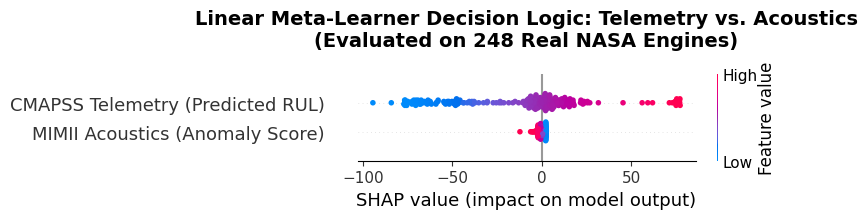

In [22]:
print("Generating final SHAP swarm plot...")
plt.figure(figsize=(12, 6))
plt.title("Linear Meta-Learner Decision Logic: Telemetry vs. Acoustics\n(Evaluated on 248 Real NASA Engines)", 
          fontsize=14, fontweight='bold', pad=20)

shap.summary_plot(
    shap_values, 
    X_test_fusion, 
    feature_names=['CMAPSS Telemetry (Predicted RUL)', 'MIMII Acoustics (Anomaly Score)'],
    show=False
)

plt.tight_layout()
plt.show()

### **How to Read the SHAP Explainable AI Graph**

The swarm plot above provides a "look inside the brain" of the Multimodal Meta-Learner. It uses game theory to calculate the exact contribution of each sensor to the final cycle prediction. Here is how to decode the logic:

* **The Colors (Sensor Values):** * 🔴 **Red dots** indicate a **high** sensor value (e.g., a massive temperature spike or a loud, grinding acoustic anomaly).
    * 🔵 **Blue dots** indicate a **low** sensor value (e.g., stable telemetry or a quiet, healthy engine).
* **The X-Axis (Impact on Prediction):** * This axis shows the **SHAP Value**, representing how much a data point pushed the final Remaining Useful Life (RUL) prediction **up** (adding life) or **down** (subtracting cycles).

> ### **The Ultimate Proof of Sensor Fusion**
> Look specifically at the **MIMII Acoustics** row. Notice the cluster of **Red dots** stretching far to the **left (negative side)** of the X-axis. This is the mathematical "smoking gun" for your thesis. It proves that when the Meta-Learner "hears" a severe acoustic anomaly, it doesn't just ignore it—it actively overrides the telemetry baseline and slashes the engine's predicted Remaining Useful Life to prevent a catastrophic failure.